In [1]:
# removing sparse columns

In [2]:
def filter_gap_columns(input_file, output_file, max_gap_percentage):
    """
    Removes columns from a FASTA alignment that exceed a certain percentage of gaps.
    
    Parameters:
    - input_file (str): Path to the input .fasta file.
    - output_file (str): Path to save the filtered .fasta file.
    - max_gap_percentage (float): Maximum allowed percentage of gaps (0 to 100).
    """
    sequences = {}
    current_header = ""
    
    # 1. Read the FASTA file
    with open(input_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                current_header = line
                sequences[current_header] = []
            else:
                sequences[current_header].append(line)

    # Join the sequence lines together for each taxon
    for header in sequences:
        sequences[header] = "".join(sequences[header])

    headers = list(sequences.keys())
    seqs = list(sequences.values())
    
    if not seqs:
        print("No sequences found.")
        return

    num_seqs = len(seqs)
    seq_len = len(seqs[0])
    
    # Check if all sequences are the same length (required for column operations)
    if any(len(seq) != seq_len for seq in seqs):
        print("Error: Not all sequences are the same length. Please ensure this is an alignment.")
        return

    # 2. Identify which columns to keep
    columns_to_keep = []
    for col_idx in range(seq_len):
        # Count the number of gaps ('-') in the current column
        gap_count = sum(1 for seq in seqs if seq[col_idx] == '-')
        gap_percentage = (gap_count / num_seqs) * 100
        
        # If the gap percentage is within our limit, save the column index
        if gap_percentage <= max_gap_percentage:
            columns_to_keep.append(col_idx)

    # 3. Reconstruct the sequences and write to the new file
    with open(output_file, 'w') as f:
        for header, seq in zip(headers, seqs):
            # Keep only the columns that passed the filter
            filtered_seq = "".join(seq[i] for i in columns_to_keep)
            f.write(f"{header}\n")
            
            # Write the sequence in chunks of 80 characters for standard FASTA formatting
            for i in range(0, len(filtered_seq), 80):
                f.write(f"{filtered_seq[i:i+80]}\n")
                
    removed_count = seq_len - len(columns_to_keep)
    print(f"Done! Removed {removed_count} columns.")
    print(f"Original length: {seq_len} | New length: {len(columns_to_keep)}")

# --- Run the function ---
# Change the max_gap_percentage to your desired threshold (e.g., 50 means a max of 50% gaps)
filter_gap_columns(
    input_file="data/DS1/DS1_reordered_tree.fasta", 
    output_file="data/DS1/DS1_reordered_tree_filtered_alignment_0_perc.fasta", 
    max_gap_percentage=0.0 
)

Done! Removed 1341 columns.
Original length: 1949 | New length: 608


Loaded alignment: N=27 taxa, L=1949 sites
Overall gap fraction: 0.2042


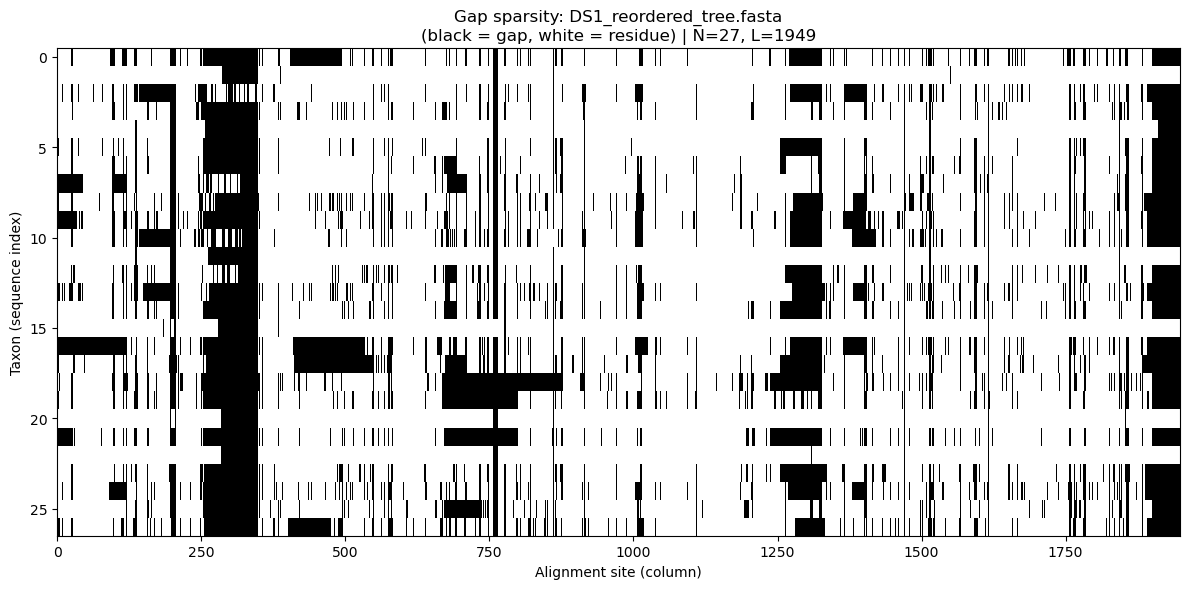

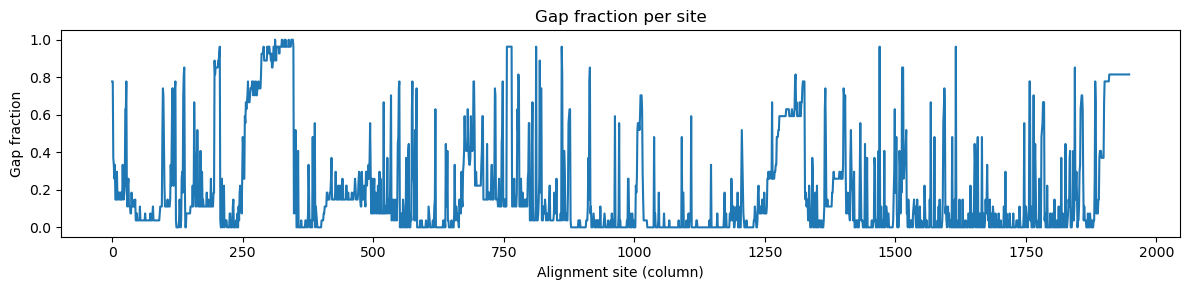

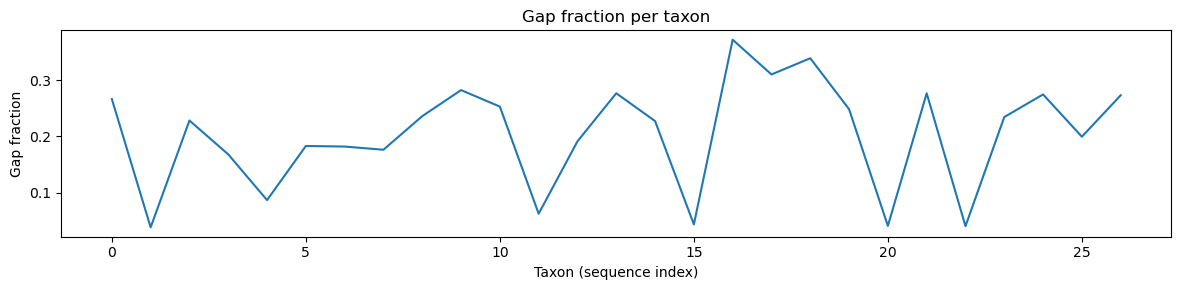

In [4]:
# --- Sparsity pattern (gaps) plot for an alignment FASTA (.fasta / .fa) ---

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------
# 1) FASTA alignment reader
# ---------------------------
def read_fasta_alignment(fasta_path: str):
    """
    Reads a FASTA multiple sequence alignment.
    Returns:
        names: list[str]
        seqs:  list[str] (all same length)
    """
    fasta_path = Path(fasta_path)
    if not fasta_path.exists():
        raise FileNotFoundError(f"File not found: {fasta_path}")

    names, seqs = [], []
    cur_name, cur_seq = None, []

    with fasta_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                # flush previous
                if cur_name is not None:
                    names.append(cur_name)
                    seqs.append("".join(cur_seq))
                cur_name = line[1:].strip()
                cur_seq = []
            else:
                cur_seq.append(line)

        # flush last
        if cur_name is not None:
            names.append(cur_name)
            seqs.append("".join(cur_seq))

    if not seqs:
        raise ValueError("No sequences found. Is this a valid FASTA?")

    Ls = {len(s) for s in seqs}
    if len(Ls) != 1:
        # If this triggers, your FASTA is not an aligned MSA (or has line issues).
        raise ValueError(f"Sequences have different lengths: {sorted(Ls)}. "
                         "This does not look like an alignment FASTA.")

    return names, seqs


# ---------------------------
# 2) Convert to gap mask
# ---------------------------
def alignment_gap_mask(seqs, gap_chars=("-", "."), uppercase=True):
    """
    Converts sequences -> boolean mask (N x L):
        True  = gap at [i, j]
        False = not-gap
    """
    if uppercase:
        seqs = [s.upper() for s in seqs]

    N = len(seqs)
    L = len(seqs[0])
    # Create a (N,L) array of characters
    arr = np.frombuffer("".join(seqs).encode("ascii", "ignore"), dtype="S1").reshape(N, L)
    # Mask gaps
    gap_bytes = {c.encode("ascii") for c in gap_chars}
    mask = np.isin(arr, list(gap_bytes))
    return mask


# ---------------------------
# 3) Plot sparsity pattern
# ---------------------------
def plot_gap_sparsity(mask, title="Gap sparsity pattern", max_taxa=None, max_sites=None):
    """
    mask: boolean (N x L), True = gap
    max_taxa/max_sites: optional downsampling (for huge alignments).
    """
    N, L = mask.shape
    mask_plot = mask

    if max_taxa is not None and N > max_taxa:
        # evenly sample rows
        idx = np.linspace(0, N - 1, max_taxa).round().astype(int)
        mask_plot = mask_plot[idx, :]
        N = mask_plot.shape[0]

    if max_sites is not None and L > max_sites:
        # evenly sample columns
        jdx = np.linspace(0, L - 1, max_sites).round().astype(int)
        mask_plot = mask_plot[:, jdx]
        L = mask_plot.shape[1]

    plt.figure(figsize=(12, 6))
    # show True as black pixels, False as white
    plt.imshow(mask_plot, aspect="auto", interpolation="nearest", cmap="gray_r")
    plt.xlabel("Alignment site (column)")
    plt.ylabel("Taxon (sequence index)")
    plt.title(f"{title}\n(black = gap, white = residue) | N={mask.shape[0]}, L={mask.shape[1]}")
    plt.tight_layout()
    plt.show()


# ---------------------------
# 4) Useful summary plots
# ---------------------------
def plot_gap_summaries(mask):
    """
    Adds:
      - gap fraction per site (column)
      - gap fraction per taxon (row)
    """
    gap_per_site = mask.mean(axis=0)  # length L
    gap_per_taxon = mask.mean(axis=1) # length N

    plt.figure(figsize=(12, 3))
    plt.plot(gap_per_site)
    plt.xlabel("Alignment site (column)")
    plt.ylabel("Gap fraction")
    plt.title("Gap fraction per site")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 3))
    plt.plot(gap_per_taxon)
    plt.xlabel("Taxon (sequence index)")
    plt.ylabel("Gap fraction")
    plt.title("Gap fraction per taxon")
    plt.tight_layout()
    plt.show()


# ---------------------------
# 5) Run it on your file
# ---------------------------
FASTA_PATH = "data/DS1/DS1_reordered_tree.fasta"  # <-- change this to your path

names, seqs = read_fasta_alignment(FASTA_PATH)
mask = alignment_gap_mask(seqs, gap_chars=("-", "."))  # treat '-' and '.' as gaps

print(f"Loaded alignment: N={len(seqs)} taxa, L={len(seqs[0])} sites")
print(f"Overall gap fraction: {mask.mean():.4f}")

plot_gap_sparsity(mask, title=f"Gap sparsity: {Path(FASTA_PATH).name}")
plot_gap_summaries(mask)